In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    MeanShift
)
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold      import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from Transformers import *  
from prince import FAMD
import warnings
warnings.filterwarnings("ignore")
import pickle
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN  
import gower


## Wczytanie danych

Wczytujemy dane po preprocessingu i przetwarzamy je ponownie przy pomocą FAMD lub odległości Gowera

In [2]:
df_train=pd.read_csv("data/TransformedData/train.csv")
df_test=pd.read_csv("data/TransformedData/test.csv") 

In [3]:
def load_famd(filepath: str):
    with open(filepath, 'rb') as f:
        famd = pickle.load(f)
    print(f"FAMD model loaded from {filepath!r}")
    return famd

In [4]:
Famd= load_famd("data/TransformedData/famd_model.pkl")
X_test= Famd.transform(df_test)
X_train= Famd.transform(df_train)

FAMD model loaded from 'data/TransformedData/famd_model.pkl'


In [35]:
X_train_gower = gower.gower_matrix(df_train)
X_test_gower = gower.gower_matrix(df_test)

## T-SNE plot function

funkcja przyjmuje dane, wykonuje na nich T-SNE i wizualizuje wyniki

In [5]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

def tsne_plot(
    X, 
    y, 
    title: str = None,
    perplexity: float = 30.0,
    random_state: int = 42,
    point_size: int = 40,
    cmap: str = "tab10"
):
    
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state
    )
    X_emb = tsne.fit_transform(X)
    
   
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        X_emb[:, 0], X_emb[:, 1], 
        c=y, 
        cmap=cmap, 
        s=point_size, 
        alpha=0.8,
        edgecolor="k",
        linewidth=0.2
    )
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    if title:
        plt.title(title)
    
   
    labels_unique = np.unique(y)

    handles = []
    for lab in labels_unique:
        handles.append(
            plt.Line2D(
                [], [], marker="o", ls="", 
                color=sc.cmap(sc.norm(lab)), 
                label=str(lab),
                markeredgecolor="k", 
                markersize=6
            )
        )
    plt.legend(
        handles=handles, 
        title="cluster", 
        bbox_to_anchor=(1.05, 1), 
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()


## KMeans Clustering

Train

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)
predicted_train = kmeans.predict(X_train)

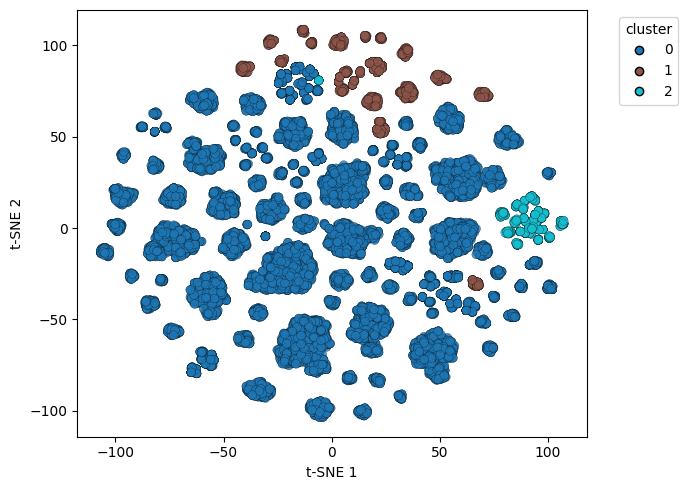

In [18]:
tsne_plot(X_train,y=predicted_train)

Test

In [7]:
predicted_test=kmeans.predict(X_test)

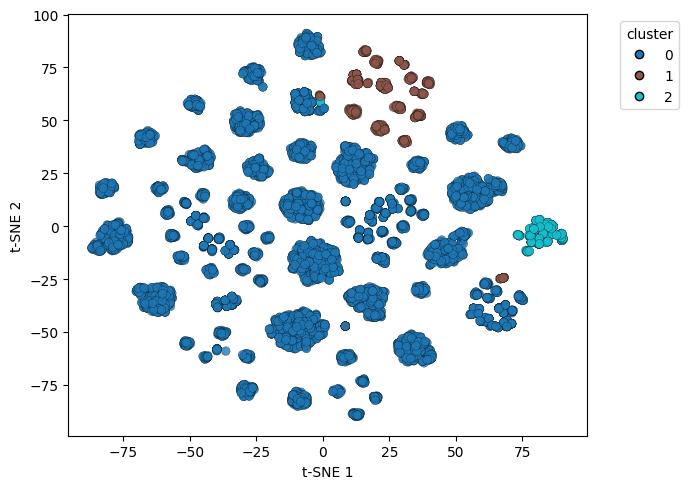

In [20]:
tsne_plot(X_test,y=predicted_test)

Z ciekawości zbadamy interpretowalność dla otrzymanych wyników

In [26]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)

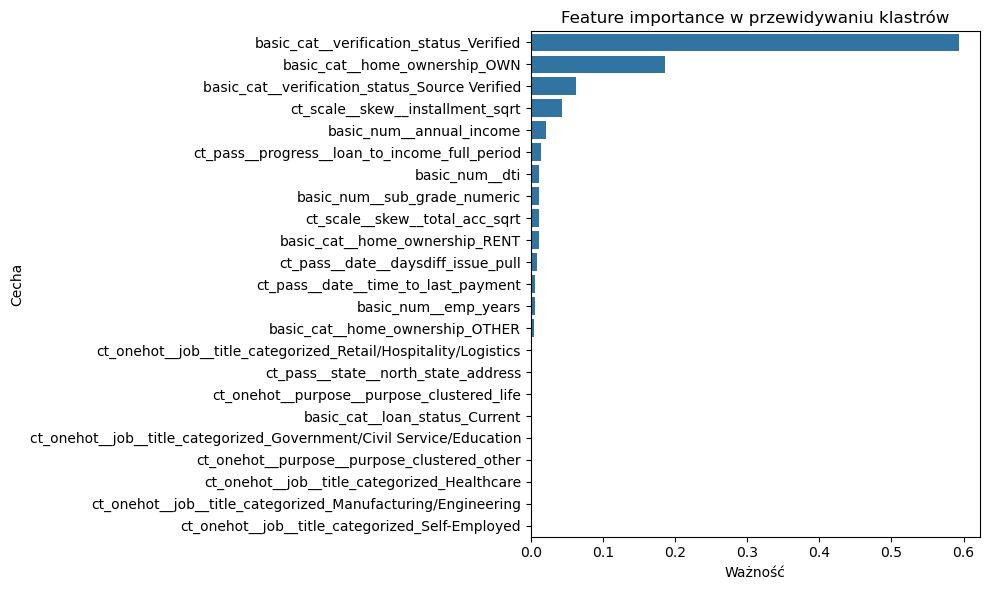

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

## Mean shift

Train

In [21]:

ms = MeanShift(bandwidth=15, n_jobs=-1)
ms.fit(X_train)
predicted_train = ms.labels_

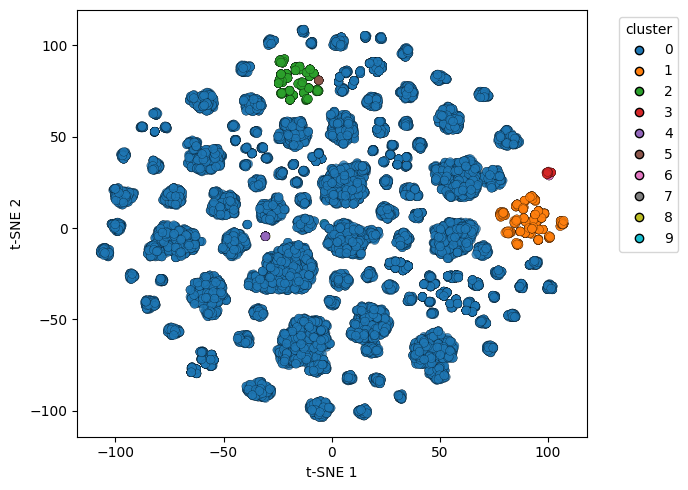

In [22]:
tsne_plot(X_train,y=predicted_train)

Test

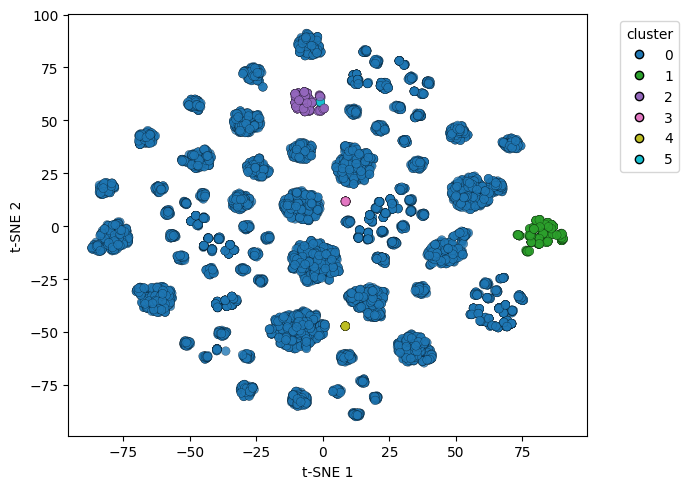

In [23]:
predicted_test = ms.predict(X_test)
tsne_plot(X_test,y=predicted_test)

## GMM 

Train

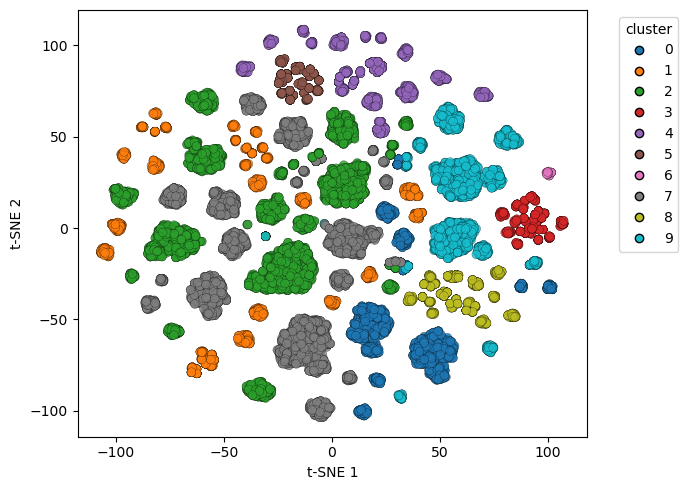

In [31]:
gmm = GaussianMixture(n_components=10, random_state=42)
gmm.fit(X_train)
predicted_train = gmm.predict(X_train)
tsne_plot(X_train,y=predicted_train)


Test

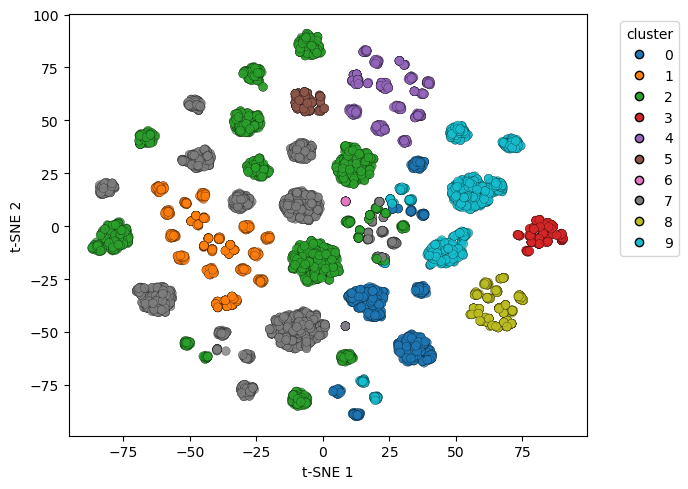

In [32]:
predicted_test = gmm.predict(X_test)
tsne_plot(X_test,y=predicted_test)

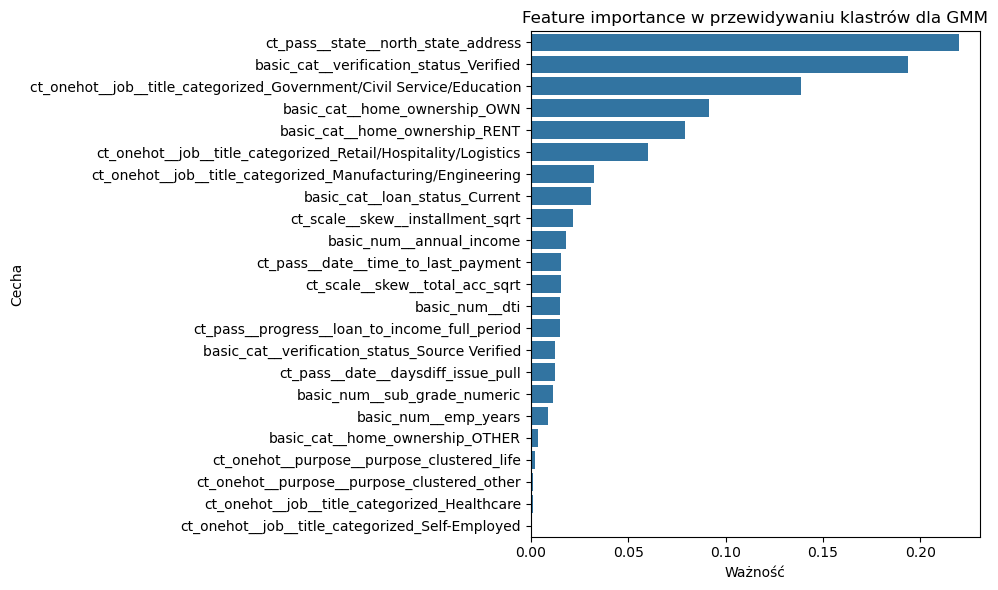

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_test, predicted_test)
feat_importances = pd.Series(rf.feature_importances_, index=df_test.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature importance w przewidywaniu klastrów dla GMM")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

## Agglomerative

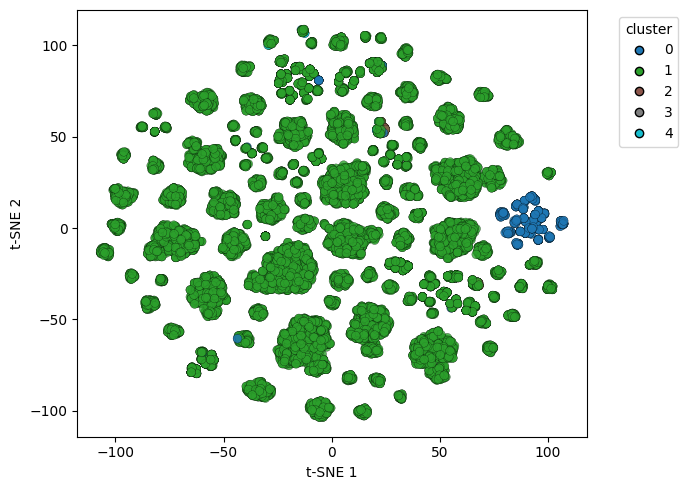

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'  
)
y_train = agg.fit_predict(X_train_gower)
tsne_plot(X_train, y=y_train)

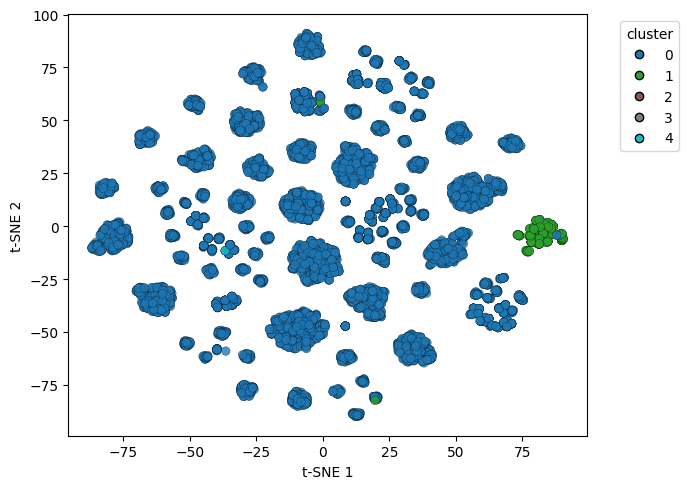

In [28]:
agg_test = AgglomerativeClustering(
    n_clusters=5,
    linkage='average',
    metric='precomputed'
)
y_test = agg_test.fit_predict(X_test_gower)
tsne_plot(X_test, y=y_test)


## Dbscan

Train

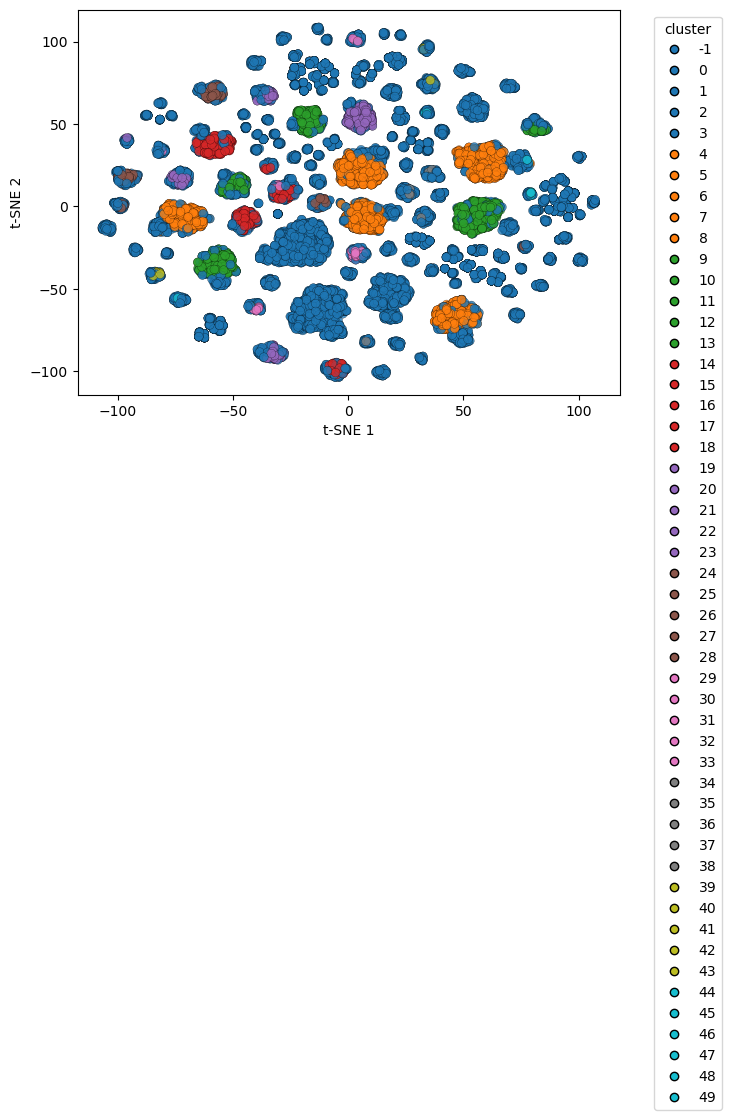

In [36]:
params={'eps': 0.03, 'min_samples': 10, 'metric' : 'precomputed'}

dbscan = DBSCAN(**params) 
predicted_train=dbscan.fit_predict(X_train_gower)

tsne_plot(X_train, y=predicted_train)


Test

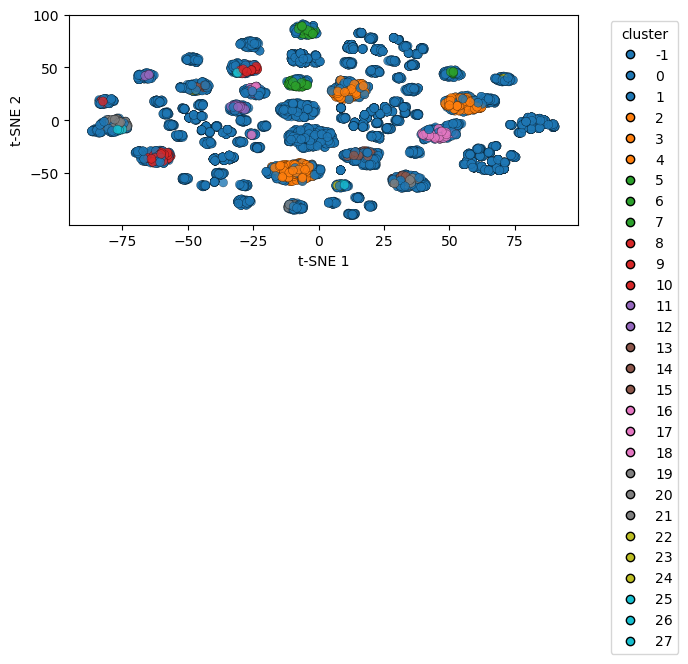

In [37]:
predicted_test = dbscan.fit_predict(X_test_gower)
tsne_plot(X_test, y=predicted_test)

Nasz finalny model na podstawie testów to ... 

## Interpretowalność

## Walidacja


In [ ]:
df_validation=pd.read_csv("data/TransformedData/validation.csv")

#tsne_plot(X_val, y=predicted_val)